# **Laboratorium: Grupowanie metodą k-średnich (K-means Clustering)**

## **Wprowadzenie do uczenia nienadzorowanego**

### **Czym jest uczenie nienadzorowane?**

W uczeniu nienadzorowanym nie mamy dostępu do etykiet (klas) dla danych. Model musi sam odkryć wzorce i struktury w danych na podstawie ich cech. Jest to przeciwieństwo uczenia nadzorowanego, gdzie mamy pary (dane wejściowe, etykieta).

### **Czym jest grupowanie (clustering)?**

Grupowanie to proces dzielenia zbioru danych na grupy (klastry) w taki sposób, aby:
- Obiekty w tej samej grupie były do siebie **podobne**
- Obiekty z różnych grup były od siebie **różne**

### **Zastosowania grupowania:**

1. **Segmentacja klientów** - dzielenie klientów na grupy o podobnych zachowaniach zakupowych
2. **Kompresja obrazów** - redukcja liczby kolorów w obrazie
3. **Analiza dokumentów** - grupowanie podobnych tekstów
4. **Biologia** - klasyfikacja gatunków na podstawie cech genetycznych
5. **Wykrywanie anomalii** - identyfikacja nietypowych wzorców w danych
6. **Analiza sieci społecznościowych** - wykrywanie społeczności

---

## **Algorytm k-średnich (k-means)**

### **Definicja**

K-means to algorytm grupowania, który dzieli $n$ obserwacji na $k$ klastrów, gdzie każda obserwacja należy do klastra z najbliższą średnią (centroidem).

### **Intuicja**

Wyobraź sobie, że masz punkty na płaszczyźnie i chcesz je podzielić na $k$ grup. K-means:
1. Losowo wybiera $k$ punktów jako początkowe centra grup (centroidy)
2. Przypisuje każdy punkt do najbliższego centroidu
3. Przesuwa centroidy do środka przypisanych punktów
4. Powtarza kroki 2-3 aż do zbieżności

### **Matematyczne podstawy**

**Funkcja kosztu (inercja/WCSS - Within-Cluster Sum of Squares):**

$$
J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

gdzie:
- $k$ - liczba klastrów
- $C_i$ - $i$-ty klaster
- $\mu_i$ - centroid $i$-tego klastra
- $x$ - punkt danych
- $||x - \mu_i||^2$ - kwadrat odległości euklidesowej

**Odległość euklidesowa:**

$$
d(x, \mu) = \sqrt{\sum_{j=1}^{n} (x_j - \mu_j)^2}
$$

**Aktualizacja centroidów:**

$$
\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x
$$

---

## **Algorytm krok po kroku**

### **Pseudokod:**

```
1. Wybierz k (liczbę klastrów)
2. Zainicjalizuj k centroidów losowo
3. Powtarzaj do zbieżności:
   a. Przypisz każdy punkt do najbliższego centroidu
   b. Oblicz nowe centroidy jako średnie punktów w każdym klastrze
4. Zwróć przypisania klastrów i centroidy
```

### **Warunek zbieżności:**

Algorytm kończy działanie gdy:
- Centroidy nie zmieniają się między iteracjami, LUB
- Przypisania punktów nie zmieniają się, LUB
- Osiągnięto maksymalną liczbę iteracji

---

### **Importujemy potrzebne biblioteki**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import seaborn as sns

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## **Implementacja algorytmu k-means od podstaw**

### **Zadanie 1: Implementacja klasy KMeansFromScratch (2 punkty)**

**Treść zadania:**

Zaimplementuj algorytm k-means od podstaw używając tylko biblioteki NumPy.

**Twoim zadaniem jest:**

1. Zaimplementować metodę `fit()` do trenowania modelu
2. Zaimplementować metodę `_assign_clusters()` do przypisywania punktów do klastrów
3. Zaimplementować metodę `_update_centroids()` do aktualizacji centroidów
4. Zaimplementować metodę `predict()` do przewidywania klastrów dla nowych danych
5. Zaimplementować metodę `inertia()` do obliczania funkcji kosztu

**Rozwiązanie:**

In [2]:
class KMeansFromScratch:
    def __init__(self, n_clusters=3, max_iters=100, random_state=2137):
        """
        Inicjalizacja algorytmu k-means
        
        Parameters:
        -----------
        n_clusters : int
            Liczba klastrów
        max_iters : int
            Maksymalna liczba iteracji
        random_state : int
            Ziarno generatora liczb losowych
        """
        # Parametry algorytmu ustawiane przez użytkownika.
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state

        # Atrybuty wyliczane po treningu modelu.
        self.centroids = np.array([])
        self.labels = np.array([])
        
    def fit(self, X):
        """Trenowanie modelu k-means"""
        # Krok 0: ustawiamy ziarno, aby wyniki były powtarzalne.
        np.random.seed(self.random_state)

        # Krok 1: losujemy indeksy punktów, które staną się centroidami startowymi.
        random_indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_indices]
        
        # Krok 2-4: iteracyjnie przypisujemy punkty i aktualizujemy centroidy.
        for iteration in range(self.max_iters):
            # Zapamiętujemy poprzednie etykiety, aby sprawdzić warunek stopu.
            old_labels = self.labels.copy()

            # Krok 2: przypisanie każdego punktu do najbliższego centroidu.
            self.labels = self._assign_clusters(X)
            
            # Krok 3: przeliczamy centroidy jako średnie punktów w klastrach.
            self._update_centroids(X)
            
            # Krok 4: jeśli przypisania się nie zmieniają, algorytm osiągnął zbieżność.
            if np.array_equal(old_labels, self.labels):
                print(f"Zbieżność osiągnięta po {iteration + 1} iteracjach")
                break
                
        return self
    
    def _assign_clusters(self, X):
        """Przypisanie każdego punktu do najbliższego centroidu"""
        # Tworzymy macierz odległości: wiersz = punkt, kolumna = centroid.
        distances = np.zeros((len(X), self.n_clusters))
        
        # Dla każdego centroidu liczymy odległość euklidesową do wszystkich punktów.
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.linalg.norm(X - centroid, axis=1)
        
        # Dla każdego punktu wybieramy indeks centroidu o najmniejszej odległości.
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X):
        """Aktualizacja centroidów jako średnie punktów w klastrze"""
        for i in range(self.n_clusters):
            # Pobieramy punkty przypisane do i-tego klastra.
            cluster_points = X[self.labels == i]

            # Jeżeli klaster nie jest pusty, liczymy nowy centroid jako średnią.
            if len(cluster_points) > 0:
                self.centroids[i] = np.mean(cluster_points, axis=0)
    
    def predict(self, X):
        """Przewidywanie klastrów dla nowych danych"""
        # Używamy aktualnych centroidów do przypisania nowych punktów.
        return self._assign_clusters(X)
    
    def inertia(self, X):
        """Obliczenie funkcji kosztu (inercji)"""
        # Inercja to suma kwadratów odległości punktów od centroidów ich klastrów.
        total_distance = 0
        for i in range(self.n_clusters):
            cluster_points = X[self.labels == i]
            total_distance += np.sum(np.linalg.norm(cluster_points - self.centroids[i], axis=1) ** 2)
        return total_distance

## **Wizualizacja danych i procesu grupowania**

### **Generowanie danych syntetycznych**

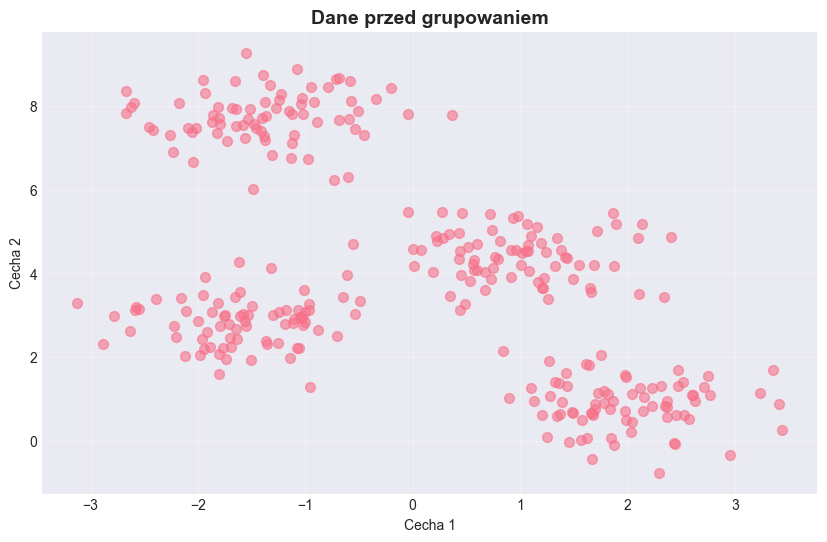

In [3]:
# Generowanie danych syntetycznych
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Wizualizacja oryginalnych danych
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6)
plt.title('Dane przed grupowaniem', fontsize=14, fontweight='bold')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.grid(True, alpha=0.3)
plt.show()

### **Testowanie naszej implementacji**

Zbieżność osiągnięta po 6 iteracjach


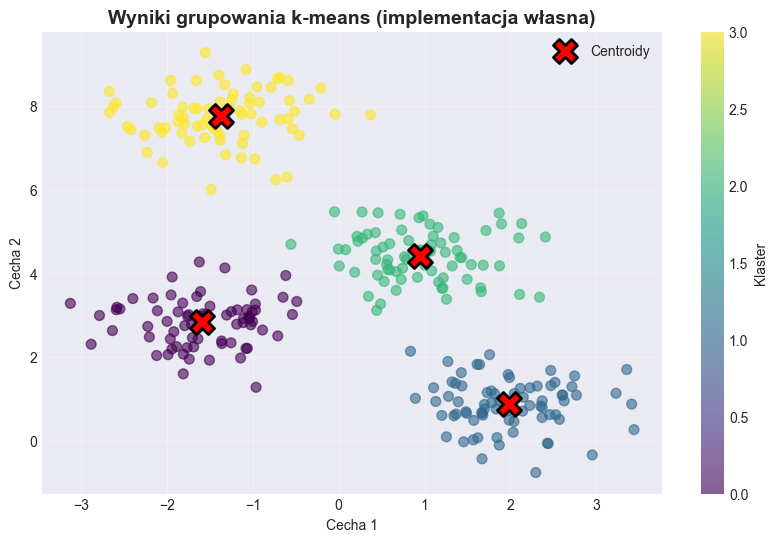

Inercja: 212.01


In [ ]:
# Trenowanie naszego modelu
kmeans_scratch = KMeansFromScratch(n_clusters=4, random_state=42)
kmeans_scratch.fit(X)

# Wizualizacja wyników
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=kmeans_scratch.labels, cmap='viridis', s=50, alpha=0.6)
plt.scatter(kmeans_scratch.centroids[:, 0], kmeans_scratch.centroids[:, 1], marker='X', s=300, c='red', edgecolors='black', linewidths=2, label='Centroidy')
plt.title('Wyniki grupowania k-means (implementacja własna)', fontsize=14, fontweight='bold')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.colorbar(scatter, label='Klaster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Inercja: {kmeans_scratch.inertia(X):.2f}")

### **Wizualizacja kroków algorytmu**

Zobaczmy jak algorytm k-means działa krok po kroku:

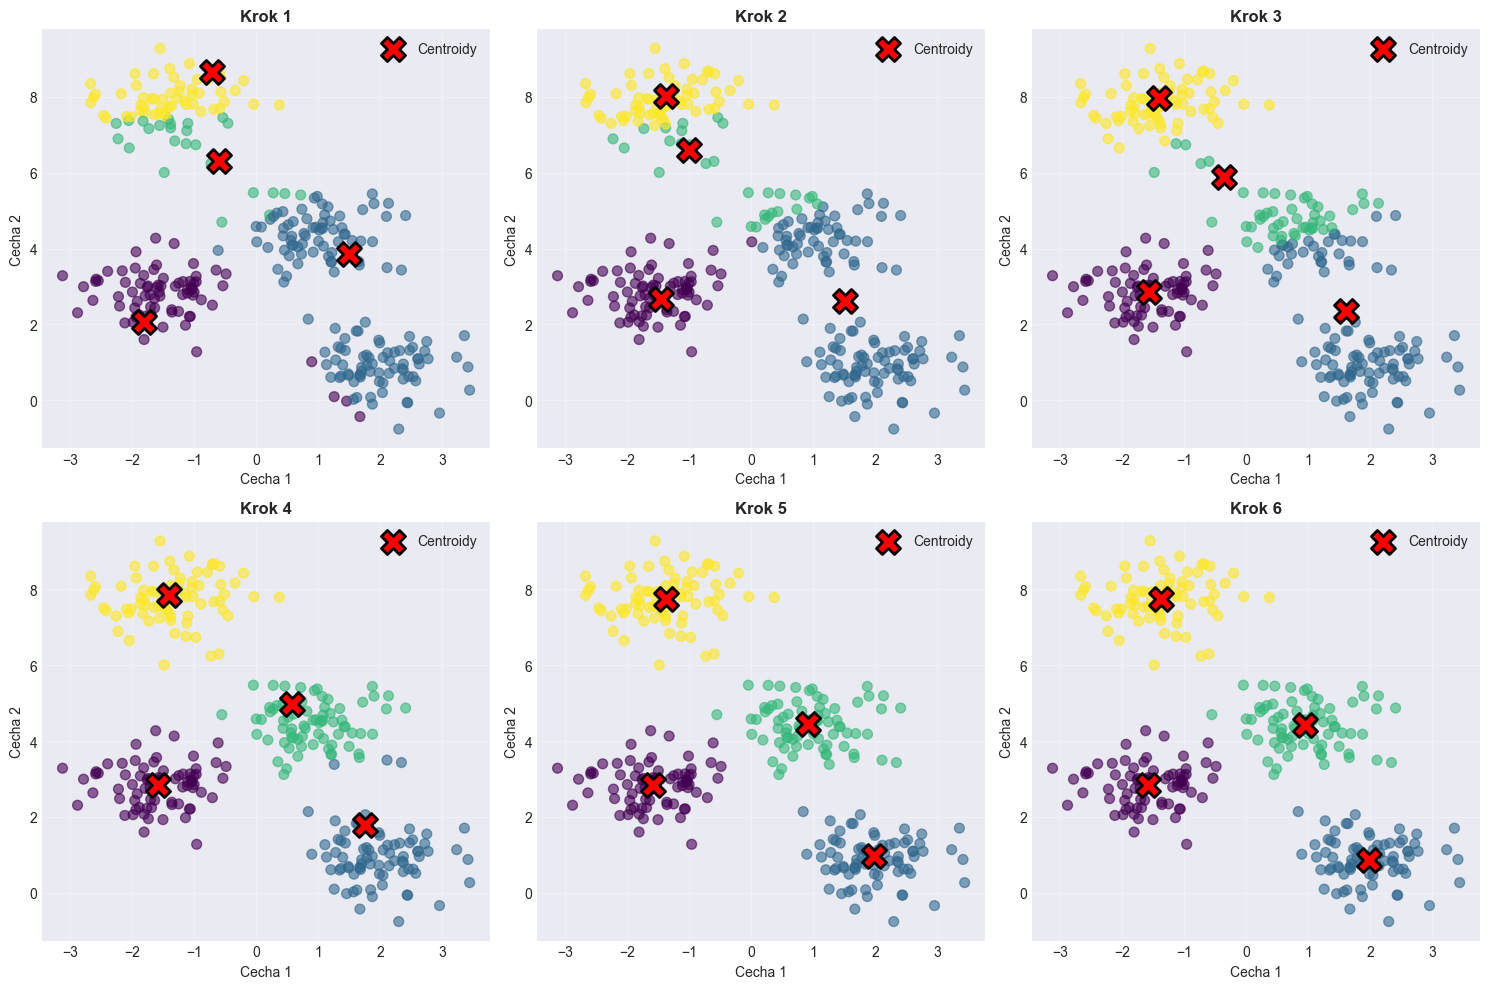

In [13]:
def visualize_kmeans_steps(X, n_clusters=4, n_steps=6):
    """Wizualizacja kolejnych kroków algorytmu k-means"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # Inicjalizacja
    np.random.seed(42)
    random_indices = np.random.choice(len(X), n_clusters, replace=False)
    centroids = X[random_indices]
    
    for step in range(min(n_steps, len(axes))):
        ax = axes[step]
        
        # Przypisanie do klastrów
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
        labels = np.argmin(distances, axis=0)
        
        # Wizualizacja
        scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, 
                           cmap='viridis', s=50, alpha=0.6)
        ax.scatter(centroids[:, 0], centroids[:, 1], 
                  marker='X', s=300, c='red', 
                  edgecolors='black', linewidths=2,
                  label='Centroidy')
        
        ax.set_title(f'Krok {step + 1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Cecha 1')
        ax.set_ylabel('Cecha 2')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Aktualizacja centroidów
        new_centroids = np.array([X[labels == i].mean(axis=0) 
                                 for i in range(n_clusters)])
        centroids = new_centroids
    
    plt.tight_layout()
    plt.show()

visualize_kmeans_steps(X, n_clusters=4, n_steps=6)

## **Wybór optymalnej liczby klastrów**

Jednym z głównych wyzwań w k-means jest wybór odpowiedniej liczby klastrów $k$. Istnieje kilka metod, które mogą nam w tym pomóc.

### **Metoda łokcia (Elbow Method)**

Metoda łokcia polega na:
1. Uruchomieniu k-means dla różnych wartości $k$
2. Obliczeniu inercji dla każdego $k$
3. Narysowaniu wykresu inercji w funkcji $k$
4. Znalezieniu "łokcia" - punktu, w którym spadek inercji zwalnia

**Zadanie 2: Implementacja metody łokcia (2 punkty)**

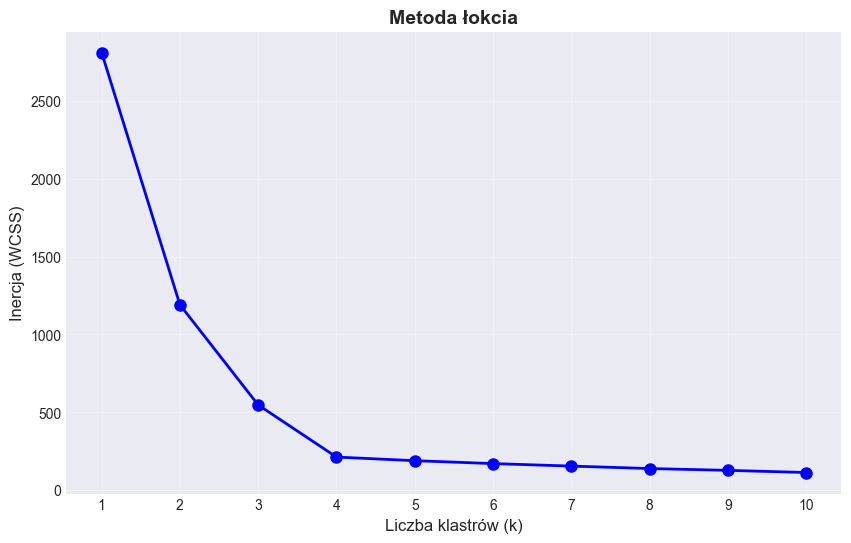

In [6]:
def elbow_method(X, max_k=10):
    """Metoda łokcia do wyboru optymalnej liczby klastrów"""

    # Lista, do której będziemy zapisywać inercję dla każdej liczby klastrów k.
    inertias = []

    # Sprawdzamy kolejne wartości k od 1 do max_k.
    K_range = range(1, max_k + 1)

    for k in K_range:
        # Krok 1: tworzymy model k-means z bieżącą liczbą klastrów.
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

        # Krok 2: uczymy model na danych X.
        kmeans.fit(X)

        # Krok 3: zapisujemy wartość inercji (WCSS) po dopasowaniu modelu.
        inertias.append(kmeans.inertia_)

    # Krok 4: rysujemy wykres inercji w funkcji liczby klastrów.
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Liczba klastrów (k)', fontsize=12)
    plt.ylabel('Inercja (WCSS)', fontsize=12)
    plt.title('Metoda łokcia', fontsize=14, fontweight='bold')
    plt.xticks(K_range)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Zwracamy listę inercji, aby można było dalej analizować wyniki.
    return inertias

inertias = elbow_method(X, max_k=10)

### **Współczynnik sylwetki (Silhouette Score)**

Współczynnik sylwetki mierzy, jak dobrze punkt pasuje do swojego klastra w porównaniu do innych klastrów.

Dla punktu $i$:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

gdzie:
- $a(i)$ - średnia odległość punktu $i$ do innych punktów w tym samym klastrze
- $b(i)$ - średnia odległość punktu $i$ do punktów w najbliższym innym klastrze

Wartości:
- $s(i) \approx 1$ - punkt jest dobrze dopasowany do swojego klastra
- $s(i) \approx 0$ - punkt jest na granicy między klastrami
- $s(i) \approx -1$ - punkt prawdopodobnie jest w złym klastrze

**Zadanie 3: Analiza współczynnika sylwetki (1 punkt)**

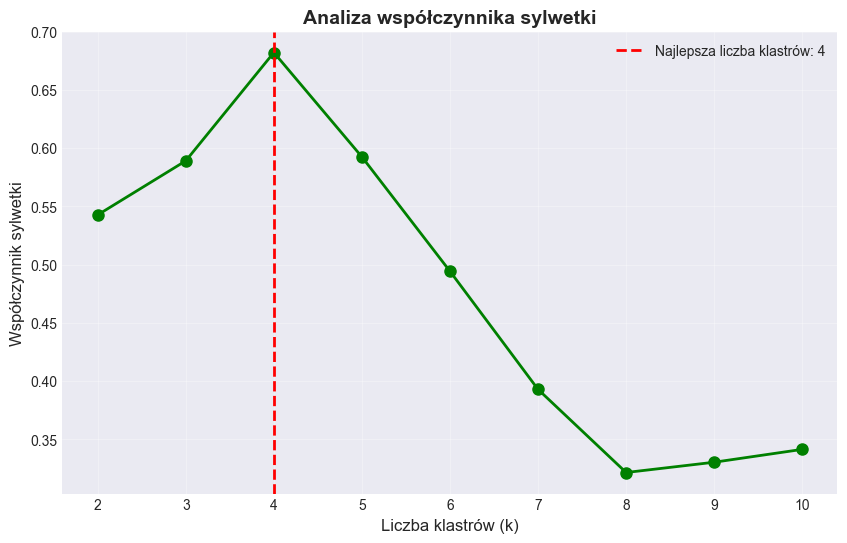

In [7]:
def silhouette_analysis(X, max_k=10):
    """Analiza współczynnika sylwetki"""
    
    # Lista na średni silhouette score dla każdej liczby klastrów.
    silhouette_scores = []

    # Silhouette jest zdefiniowany dla co najmniej 2 klastrów.
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        # Krok 1: budujemy model dla bieżącej wartości k.
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

        # Krok 2: jednocześnie dopasowujemy model i pobieramy etykiety klastrów.
        labels = kmeans.fit_predict(X)

        # Krok 3: liczymy średni współczynnik sylwetki i zapisujemy go do listy.
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
    
    # Wizualizacja
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    plt.xlabel('Liczba klastrów (k)', fontsize=12)
    plt.ylabel('Współczynnik sylwetki', fontsize=12)
    plt.title('Analiza współczynnika sylwetki', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(K_range)
    
    # Zaznaczenie maksimum
    best_k = list(K_range)[np.argmax(silhouette_scores)]
    plt.axvline(x=best_k, color='r', linestyle='--', 
                label=f'Najlepsza liczba klastrów: {best_k}', linewidth=2)
    plt.legend()
    plt.show()
    
    return silhouette_scores

silhouette_scores = silhouette_analysis(X, max_k=10)

### **Szczegółowy wykres sylwetki**

Wykres sylwetki pokazuje współczynnik sylwetki dla każdego punktu w każdym klastrze.

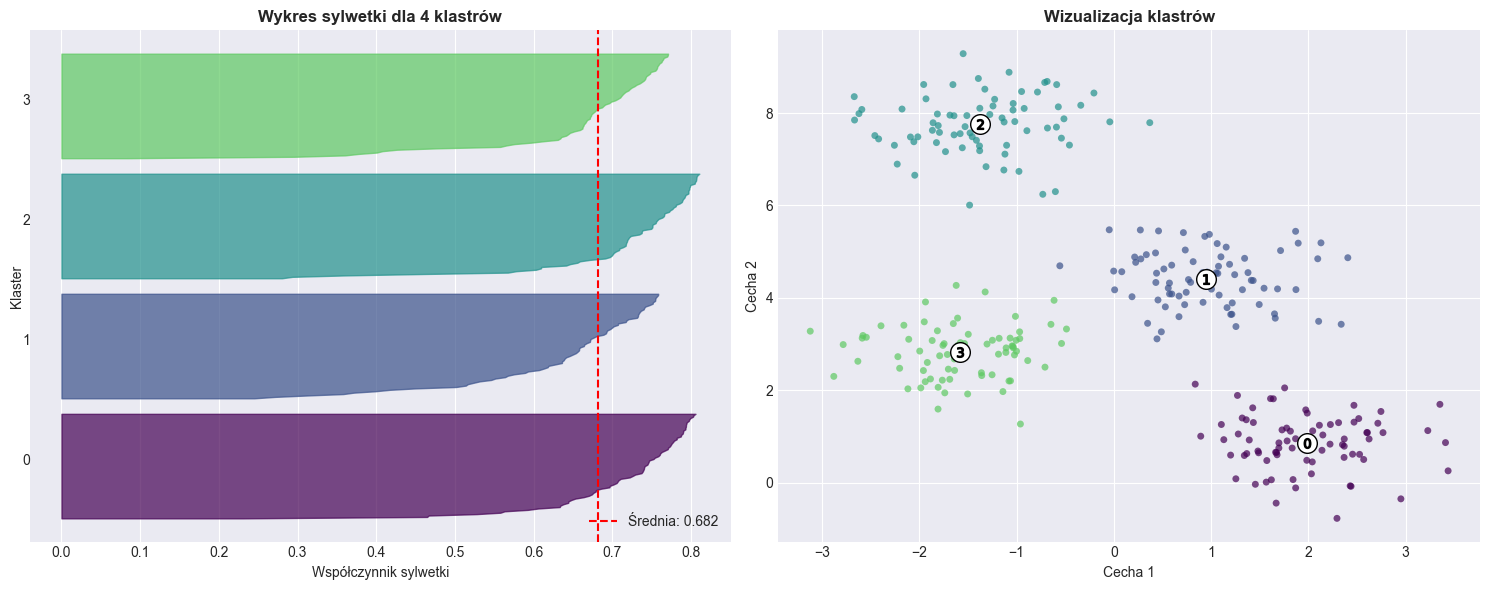

In [8]:
def plot_silhouette(X, n_clusters):
    """Szczegółowy wykres sylwetki dla danej liczby klastrów"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # Współczynniki sylwetki dla każdego punktu
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = silhouette_score(X, labels)
    
    # Wykres sylwetki
    y_lower = 10
    for i in range(n_clusters):
        cluster_silhouette_vals = silhouette_vals[labels == i]
        cluster_silhouette_vals.sort()
        
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = plt.cm.viridis(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, cluster_silhouette_vals,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax1.set_title(f'Wykres sylwetki dla {n_clusters} klastrów', 
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('Współczynnik sylwetki')
    ax1.set_ylabel('Klaster')
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", 
                label=f'Średnia: {silhouette_avg:.3f}')
    ax1.legend()
    ax1.set_yticks([])
    
    # Wizualizacja klastrów
    colors = plt.cm.viridis(labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=100, 
               lw=0, alpha=0.7, c=colors, edgecolor='k')
    
    centers = kmeans.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
               c="white", alpha=1, s=200, edgecolor='k')
    
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                   s=50, edgecolor='k')
    
    ax2.set_title('Wizualizacja klastrów', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Cecha 1')
    ax2.set_ylabel('Cecha 2')
    
    plt.tight_layout()
    plt.show()

plot_silhouette(X, n_clusters=4)

## **Praktyczne zastosowania**

### **Zadanie 4: Segmentacja klientów (1 punkt)**

**Treść zadania:**

Firma chce podzielić swoich klientów na segmenty na podstawie wieku i dochodu rocznego. Użyj k-means do segmentacji klientów.

**Rozwiązanie:**

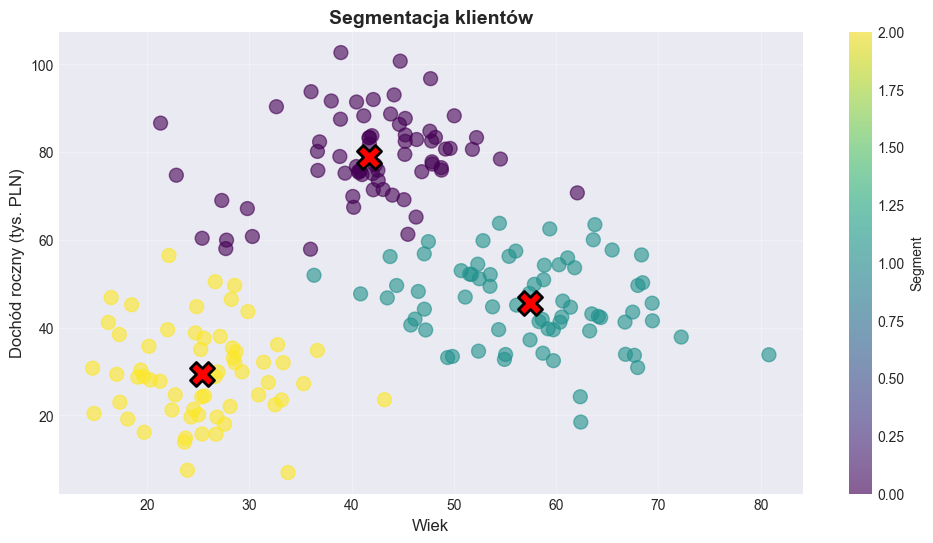


=== Analiza segmentów klientów ===

Segment 0:
  Liczba klientów: 68
  Średni wiek: 41.7 lat
  Średni dochód: 78.9 tys. PLN

Segment 1:
  Liczba klientów: 72
  Średni wiek: 57.4 lat
  Średni dochód: 45.7 tys. PLN

Segment 2:
  Liczba klientów: 60
  Średni wiek: 25.4 lat
  Średni dochód: 29.5 tys. PLN


In [9]:
# Generowanie danych klientów
np.random.seed(42)
n_customers = 200

# Cechy: wiek, dochód roczny (w tysiącach PLN)
age = np.random.normal(40, 15, n_customers)
income = np.random.normal(50, 20, n_customers)

# Dodanie struktury - różne segmenty klientów
age[:50] = np.random.normal(25, 5, 50)  # Młodzi
income[:50] = np.random.normal(30, 10, 50)

age[50:100] = np.random.normal(45, 5, 50)  # Średni wiek, wysoki dochód
income[50:100] = np.random.normal(80, 10, 50)

age[100:150] = np.random.normal(60, 5, 50)  # Starsi
income[100:150] = np.random.normal(45, 10, 50)

customers = np.column_stack([age, income])

# Grupowanie
# Krok 1: tworzymy model z 3 klastrami (zakładamy 3 główne segmenty klientów).
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Krok 2: dopasowujemy model do danych klientów i pobieramy etykiety segmentów.
segments = kmeans.fit_predict(customers)

# Wizualizacja
plt.figure(figsize=(12, 6))
scatter = plt.scatter(customers[:, 0], customers[:, 1], 
                     c=segments, cmap='viridis', s=100, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1],
           marker='X', s=300, c='red', edgecolors='black', linewidths=2)

plt.xlabel('Wiek', fontsize=12)
plt.ylabel('Dochód roczny (tys. PLN)', fontsize=12)
plt.title('Segmentacja klientów', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Segment')
plt.grid(True, alpha=0.3)
plt.show()

# Analiza segmentów
print("\n=== Analiza segmentów klientów ===")
for i in range(3):
    # Krok 3: wybieramy dane klientów z i-tego segmentu.
    segment_data = customers[segments == i]

    # Krok 4: raportujemy podstawowe statystyki segmentu.
    print(f"\nSegment {i}:")
    print(f"  Liczba klientów: {len(segment_data)}")
    print(f"  Średni wiek: {segment_data[:, 0].mean():.1f} lat")
    print(f"  Średni dochód: {segment_data[:, 1].mean():.1f} tys. PLN")

### **Zadanie 5: Kompresja obrazu (1 punkt)**

**Treść zadania:**

Użyj k-means do kompresji obrazu przez redukcję liczby kolorów.

**Rozwiązanie:**

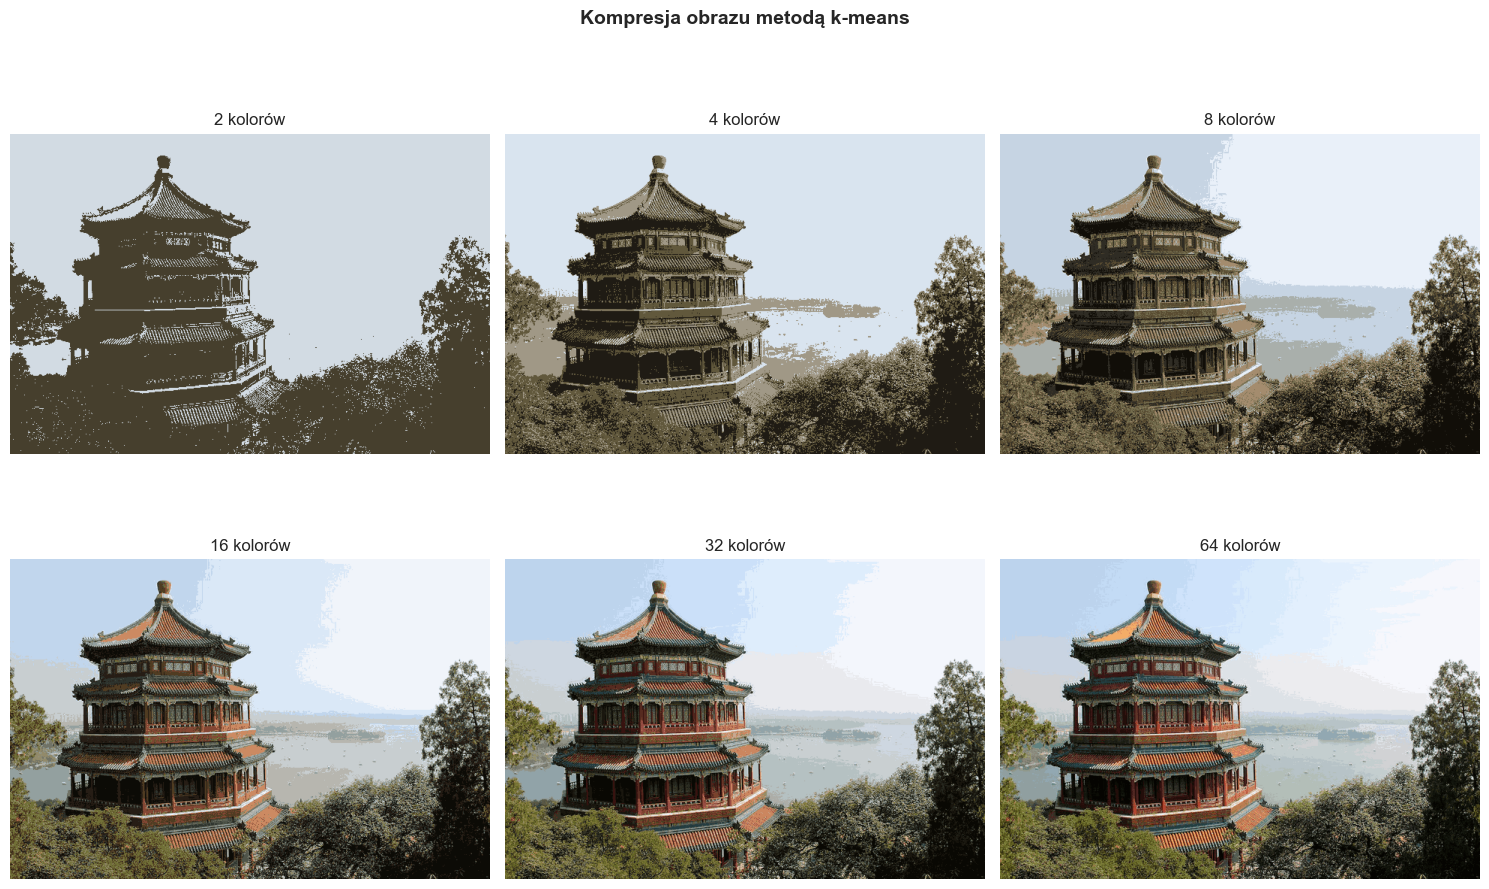

In [10]:
from sklearn.datasets import load_sample_image
from sklearn.utils import shuffle

def compress_image(image, n_colors=16):
    """Kompresja obrazu przez redukcję liczby kolorów"""

    # Krok 1: normalizujemy wartości pikseli do zakresu [0, 1].
    image_float = np.array(image, dtype=np.float64) / 255.0

    # Krok 2: spłaszczamy obraz do listy pikseli RGB o kształcie (liczba_pikseli, 3).
    w, h, d = image_float.shape
    pixels = image_float.reshape((w * h, d))

    # Krok 3: losujemy podzbiór pikseli, aby szybciej wyznaczyć centroidy kolorów.
    sample = shuffle(pixels, random_state=42, n_samples=1000)

    # Krok 4: uczymy k-means, gdzie klastry reprezentują paletę kolorów obrazu.
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    kmeans.fit(sample)

    # Krok 5: przypisujemy każdy piksel do najbliższego centroidu kolorów.
    labels = kmeans.predict(pixels)

    # Krok 6: odtwarzamy obraz, zastępując każdy piksel kolorem centroidu.
    compressed_pixels = kmeans.cluster_centers_[labels]
    compressed_image = compressed_pixels.reshape((w, h, d))

    # Krok 7: konwertujemy z powrotem do formatu 8-bitowego (0-255).
    return (compressed_image * 255).astype(np.uint8)

# Wczytanie przykładowego obrazu
china = load_sample_image("china.jpg")

# Kompresja z różną liczbą kolorów
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

color_counts = [2, 4, 8, 16, 32, 64]

for idx, n_colors in enumerate(color_counts):
    compressed = compress_image(china, n_colors)
    axes[idx].imshow(compressed)
    axes[idx].set_title(f'{n_colors} kolorów', fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Kompresja obrazu metodą k-means', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Zalety i wady k-means**

### ✅ **Zalety:**

1. **Prostota** - łatwy do zrozumienia i implementacji
2. **Szybkość** - efektywny dla dużych zbiorów danych (złożoność $O(n \cdot k \cdot i)$)
3. **Skalowalność** - dobrze działa z wieloma wymiarami
4. **Gwarancja zbieżności** - zawsze znajdzie rozwiązanie (może być lokalne minimum)

### ❌ **Wady:**

1. **Wymaga określenia k** - trzeba znać liczbę klastrów z góry
2. **Wrażliwość na inicjalizację** - różne wyniki dla różnych startów
3. **Wrażliwość na wartości odstające** - outliers wpływają na centroidy
4. **Zakłada kuliste klastry** - nie radzi sobie z nietypowymi kształtami
5. **Wrażliwość na skalę** - cechy o większych wartościach dominują

### **Kiedy używać k-means?**

- Znamy przybliżoną liczbę grup
- Klastry mają podobne rozmiary
- Klastry są w przybliżeniu kuliste
- Dane są znormalizowane

### **Alternatywy:**

- **DBSCAN** - dla klastrów o dowolnym kształcie
- **Hierarchiczne grupowanie** - gdy chcemy hierarchię klastrów
- **Gaussian Mixture Models** - dla klastrów o różnych kształtach
- **Mean Shift** - nie wymaga określenia k

---

## **Zaawansowane tematy**

### **K-means++ (lepsza inicjalizacja)**

K-means++ to ulepszona metoda inicjalizacji centroidów, która:
1. Wybiera pierwszy centroid losowo
2. Dla każdego kolejnego centroidu:
   - Oblicza odległość każdego punktu do najbliższego już wybranego centroidu
   - Wybiera nowy centroid z prawdopodobieństwem proporcjonalnym do kwadratu tej odległości

To sprawia, że centroidy są bardziej rozproszone na początku.

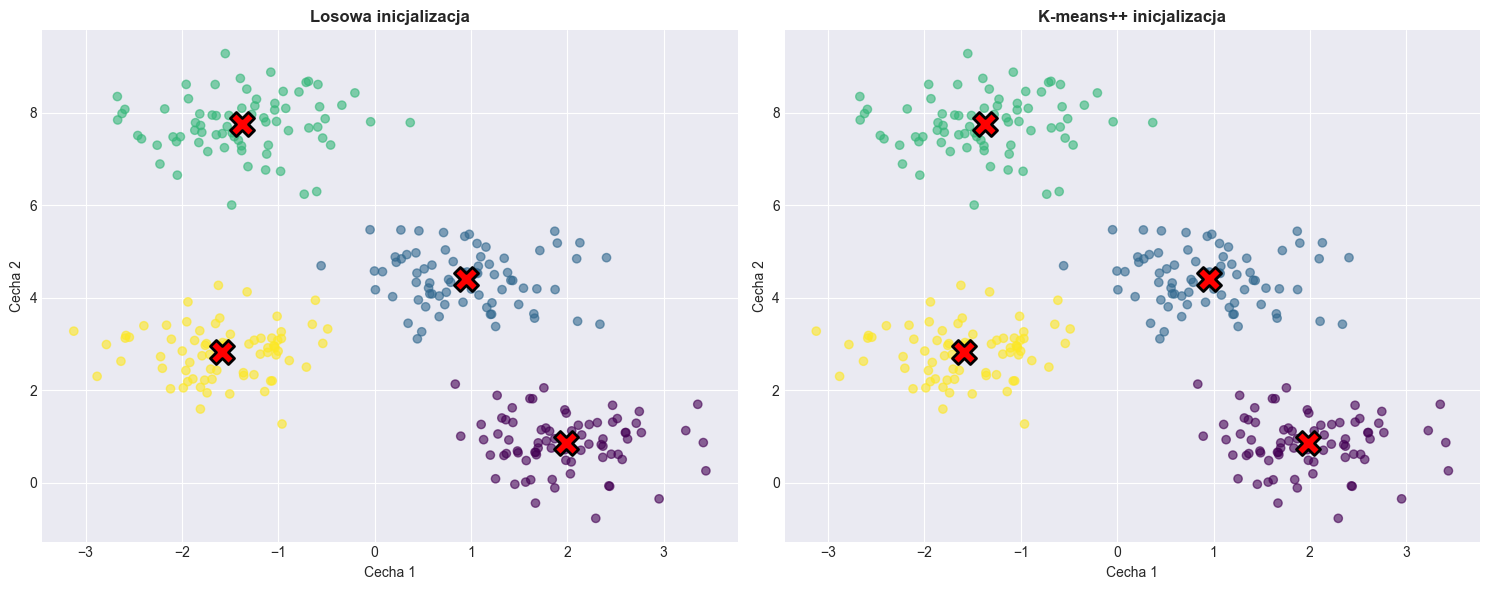

Inercja (losowa): 212.01
Inercja (k-means++): 212.01


In [11]:
# Porównanie inicjalizacji
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Losowa inicjalizacja
kmeans_random = KMeans(n_clusters=4, init='random', n_init=1, random_state=42)
labels_random = kmeans_random.fit_predict(X)

ax1.scatter(X[:, 0], X[:, 1], c=labels_random, cmap='viridis', alpha=0.6)
ax1.scatter(kmeans_random.cluster_centers_[:, 0], 
           kmeans_random.cluster_centers_[:, 1],
           marker='X', s=300, c='red', edgecolors='black', linewidths=2)
ax1.set_title('Losowa inicjalizacja', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cecha 1')
ax1.set_ylabel('Cecha 2')

# K-means++ inicjalizacja
kmeans_pp = KMeans(n_clusters=4, init='k-means++', n_init=1, random_state=42)
labels_pp = kmeans_pp.fit_predict(X)

ax2.scatter(X[:, 0], X[:, 1], c=labels_pp, cmap='viridis', alpha=0.6)
ax2.scatter(kmeans_pp.cluster_centers_[:, 0], 
           kmeans_pp.cluster_centers_[:, 1],
           marker='X', s=300, c='red', edgecolors='black', linewidths=2)
ax2.set_title('K-means++ inicjalizacja', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cecha 1')
ax2.set_ylabel('Cecha 2')

plt.tight_layout()
plt.show()

print(f"Inercja (losowa): {kmeans_random.inertia_:.2f}")
print(f"Inercja (k-means++): {kmeans_pp.inertia_:.2f}")

### 📝 **Zadanie 7: Wykrywanie anomalii (2 punkty)**

Użyj k-means do wykrywania anomalii w danych. Punkty daleko od wszystkich centroidów mogą być anomaliami.

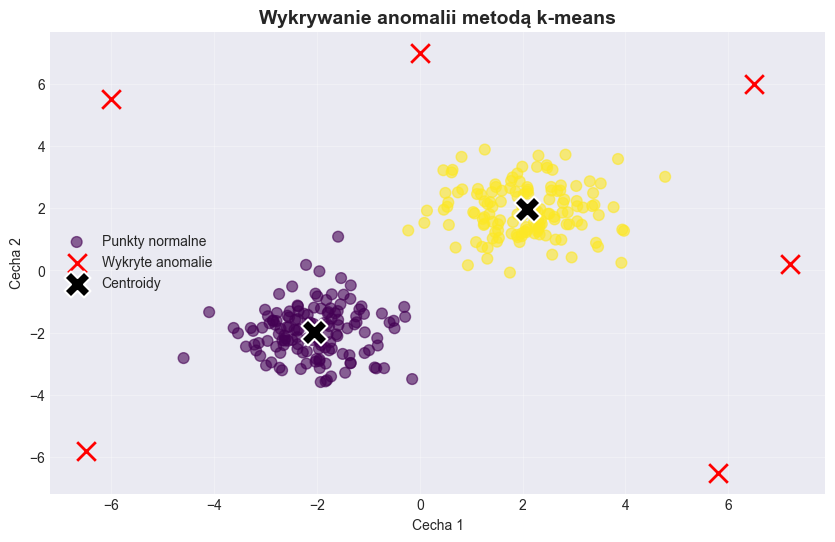

Próg anomalii (98 percentyl): 3.789
Liczba wykrytych anomalii: 6 / 286


In [12]:
# 1. Wygeneruj dane z kilkoma anomaliami
# Tworzymy dwa główne skupiska punktów (dane "normalne").
X_normal, _ = make_blobs(
    n_samples=280,
    centers=[[-2, -2], [2, 2]],
    cluster_std=[0.8, 0.9],
    random_state=42
)

# Dodajemy kilka punktów oddalonych od skupisk (potencjalne anomalie).
anomalies_true = np.array([
    [6.5, 6.0],
    [-6.0, 5.5],
    [5.8, -6.5],
    [-6.5, -5.8],
    [0.0, 7.0],
    [7.2, 0.2]
])

# Łączymy dane normalne z anomaliami w jeden zbiór.
X_anomaly = np.vstack([X_normal, anomalies_true])

# 2. Zastosuj k-means
# Uczymy model na całym zbiorze; centroidy opisują "typowe" obszary danych.
kmeans_anomaly = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_anomaly = kmeans_anomaly.fit_predict(X_anomaly)

# 3. Oblicz odległość każdego punktu do najbliższego centroidu
# Pobieramy odległości do wszystkich centroidów i wybieramy minimum dla każdego punktu.
all_distances = kmeans_anomaly.transform(X_anomaly)
min_distances = np.min(all_distances, axis=1)

# 4. Zidentyfikuj anomalie jako punkty z największą odległością
# Ustalamy próg na 98 percentylu - najbardziej odległe ~2% punktów traktujemy jako anomalie.
threshold = np.percentile(min_distances, 98)
is_anomaly = min_distances >= threshold

# 5. Zwizualizuj wyniki
plt.figure(figsize=(10, 6))

# Punkty normalne.
plt.scatter(
    X_anomaly[~is_anomaly, 0],
    X_anomaly[~is_anomaly, 1],
    c=labels_anomaly[~is_anomaly],
    cmap='viridis',
    s=60,
    alpha=0.6,
    label='Punkty normalne'
)

# Punkty wykryte jako anomalie.
plt.scatter(
    X_anomaly[is_anomaly, 0],
    X_anomaly[is_anomaly, 1],
    c='red',
    marker='x',
    s=180,
    linewidths=2,
    label='Wykryte anomalie'
)

# Centroidy klastrów.
plt.scatter(
    kmeans_anomaly.cluster_centers_[:, 0],
    kmeans_anomaly.cluster_centers_[:, 1],
    marker='X',
    s=350,
    c='black',
    edgecolors='white',
    linewidths=1.5,
    label='Centroidy'
)

plt.title('Wykrywanie anomalii metodą k-means', fontsize=14, fontweight='bold')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Próg anomalii (98 percentyl): {threshold:.3f}")
print(f"Liczba wykrytych anomalii: {is_anomaly.sum()} / {len(X_anomaly)}")

## **Podsumowanie**

### **Kluczowe wnioski:**

1. **K-means** to prosty i efektywny algorytm grupowania
2. Wymaga określenia liczby klastrów $k$ z góry
3. Używaj **metody łokcia** i **współczynnika sylwetki** do wyboru $k$
4. **K-means++** poprawia inicjalizację i przyspiesza zbieżność
5. **Normalizacja danych** jest kluczowa przed zastosowaniem k-means
6. Algorytm jest **wrażliwy na wartości odstające**
7. Najlepiej działa dla **kulistych klastrów** o podobnych rozmiarach